In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


In [2]:
df = pd.read_csv('viajaco_colombia.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"→ {df.shape[0]} viajeros, {df.shape[1]} variables\n")
df.head()

Dimensiones del dataset: (1500, 10)
→ 1500 viajeros, 10 variables



,viajero_id,ciudad_origen,destino_preferido,tipo_viaje,canal_reserva,edad,gasto_promedio_cop,frecuencia_anual,noches_promedio,satisfaccion
0,VCO0001,Manizales,Eje Cafetero,Aventura,App móvil,18,345617,2.7,4.1,3.7
1,VCO0002,Bogotá,Medellín,Cultural,Reserva directa,46,1940263,1.2,2.2,5.0
2,VCO0003,Barranquilla,San Andrés,Descanso,Agencia tradicional,40,1309613,3.2,3.2,4.6
3,VCO0004,Barranquilla,Cartagena,Descanso,Reserva directa,33,932102,1.7,6.6,4.0
4,VCO0005,Bogotá,Santa Marta,Aventura,Recomendación,30,310989,2.0,4.3,3.0


In [3]:
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Tipos de datos:
viajero_id                str
ciudad_origen             str
destino_preferido         str
tipo_viaje                str
canal_reserva             str
edad                    int64
gasto_promedio_cop      int64
frecuencia_anual      float64
noches_promedio       float64
satisfaccion          float64
dtype: object

Valores nulos por columna:
viajero_id            0
ciudad_origen         0
destino_preferido     0
tipo_viaje            0
canal_reserva         0
edad                  0
gasto_promedio_cop    0
frecuencia_anual      0
noches_promedio       0
satisfaccion          0
dtype: int64


In [4]:
df.describe().round(2)

,edad,gasto_promedio_cop,frecuencia_anual,noches_promedio,satisfaccion
count,1500.00,1500.00,1500.00,1500.00,1500.00
mean,34.35,1189147.06,2.88,4.38,4.33
std,8.82,860673.49,1.55,1.51,0.45
min,18.00,150000.00,1.00,1.00,2.50
25%,27.00,381947.50,1.70,3.30,4.00
50%,34.00,1088448.00,2.40,4.20,4.40
75%,41.00,1751357.00,4.00,5.40,4.70
max,60.00,3310726.00,7.80,10.00,5.00


In [5]:
variables_numericas = ['edad', 'gasto_promedio_cop', 'frecuencia_anual', 
                       'noches_promedio', 'satisfaccion']

X = df[variables_numericas].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape de X_scaled: {X_scaled.shape}")
print(f"\nMedia por columna después del escalado (debe ser ≈ 0):")
print(X_scaled.mean(axis=0).round(4))
print(f"\nDesviación estándar por columna después del escalado (debe ser ≈ 1):")
print(X_scaled.std(axis=0).round(4))

Shape de X_scaled: (1500, 5)

Media por columna después del escalado (debe ser ≈ 0):
[-0.  0. -0. -0.  0.]

Desviación estándar por columna después del escalado (debe ser ≈ 1):
[1. 1. 1. 1. 1.]


In [6]:
inercias = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    print(f"K={k:2d} → Inercia: {kmeans.inertia_:,.2f}")

print("\nCálculo completado")

K= 2 → Inercia: 4,028.70
K= 3 → Inercia: 3,102.55
K= 4 → Inercia: 2,629.23
K= 5 → Inercia: 2,346.78
K= 6 → Inercia: 2,173.35
K= 7 → Inercia: 2,042.41
K= 8 → Inercia: 1,913.35
K= 9 → Inercia: 1,803.19
K=10 → Inercia: 1,715.13

Cálculo completado


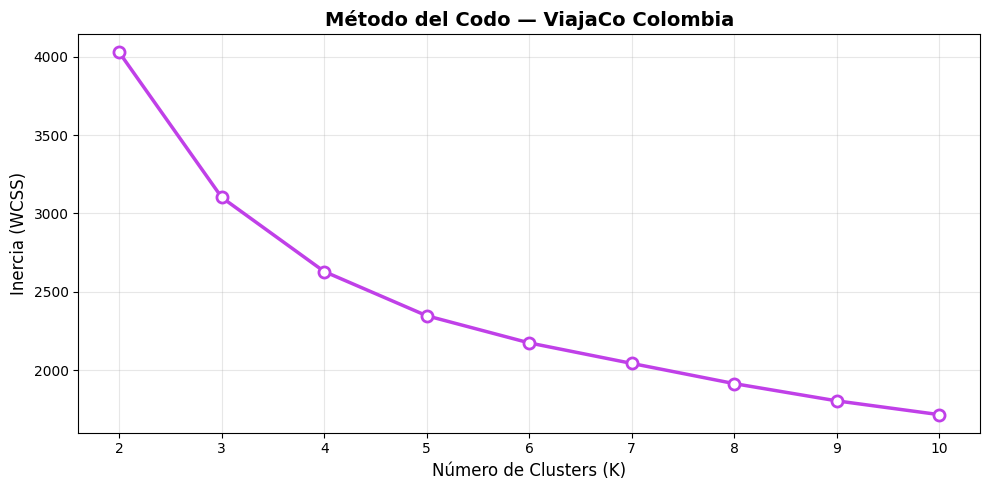

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(valores_k, inercias, marker='o', color='#c040e8', linewidth=2.5, 
         markersize=8, markerfacecolor='white', markeredgewidth=2)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.title('Método del Codo — ViajaCo Colombia', fontsize=14, fontweight='bold')
plt.xticks(valores_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

df['cluster'] = kmeans_final.labels_

print(f"Clusters asignados: {sorted(df['cluster'].unique())}")
print(f"\nDistribución de clusters (cantidad de viajeros):")
print(df['cluster'].value_counts().sort_index())
print(f"\nPorcentaje de viajeros por cluster:")
print((df['cluster'].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + '%')

Clusters asignados: [np.int32(0), np.int32(1), np.int32(2)]

Distribución de clusters (cantidad de viajeros):
cluster
0    512
1    401
2    587
Name: count, dtype: int64

Porcentaje de viajeros por cluster:
cluster
0    34.1%
1    26.7%
2    39.1%
Name: proportion, dtype: str


In [9]:
perfil_numerico = df.groupby('cluster')[variables_numericas].mean().round(2)
print("=== PERFIL PROMEDIO POR CLUSTER ===\n")
print(perfil_numerico.to_string())

=== PERFIL PROMEDIO POR CLUSTER ===

          edad  gasto_promedio_cop  frecuencia_anual  noches_promedio  satisfaccion
cluster                                                                            
0        37.24          1202814.17              2.12             5.75          4.38
1        43.42          2370789.96              1.53             3.96          4.62
2        25.64           370005.05              4.47             3.46          4.09


In [10]:
print("=== TIPO DE VIAJE POR CLUSTER ===")
print(df.groupby('cluster')['tipo_viaje'].value_counts().unstack(fill_value=0))

print("\n=== DESTINO PREFERIDO POR CLUSTER ===")
print(df.groupby('cluster')['destino_preferido'].value_counts().unstack(fill_value=0))

print("\n=== CANAL DE RESERVA POR CLUSTER ===")
print(df.groupby('cluster')['canal_reserva'].value_counts().unstack(fill_value=0))

=== TIPO DE VIAJE POR CLUSTER ===
tipo_viaje  Aventura  Cultural  Descanso  Ecoturismo  Gastronómico
cluster                                                           
0                  4       104       269           2           133
1                  0       165        89           0           147
2                272       132         8         172             3

=== DESTINO PREFERIDO POR CLUSTER ===
destino_preferido  Amazonas  Cartagena  Eje Cafetero  Medellín  San Andrés  \
cluster                                                                      
0                         2        218            59         3         145   
1                         0        148             8        55         108   
2                       130          6           231         0           5   

destino_preferido  Santa Marta  Villa de Leyva  
cluster                                         
0                           82               3  
1                            4              78  
2    

In [11]:
nombres_cluster = {
    0: 'El joven',   
    1: 'La Familia',       
    2: 'El Ejecutivo'      
}
df['perfil'] = df['cluster'].map(nombres_cluster)

print(df[['viajero_id', 'cluster', 'perfil', 'gasto_promedio_cop', 
          'frecuencia_anual', 'tipo_viaje']].head(15).to_string())

   viajero_id  cluster        perfil  gasto_promedio_cop  frecuencia_anual    tipo_viaje
0     VCO0001        2  El Ejecutivo              345617               2.7      Aventura
1     VCO0002        1    La Familia             1940263               1.2      Cultural
2     VCO0003        1    La Familia             1309613               3.2      Descanso
3     VCO0004        0      El joven              932102               1.7      Descanso
4     VCO0005        2  El Ejecutivo              310989               2.0      Aventura
5     VCO0006        2  El Ejecutivo              235099               5.1      Aventura
6     VCO0007        2  El Ejecutivo              405513               6.3      Aventura
7     VCO0008        1    La Familia             2225307               1.0  Gastronómico
8     VCO0009        0      El joven             1417044               2.0  Gastronómico
9     VCO0010        0      El joven             1207711               1.0  Gastronómico
10    VCO0011        